In [3]:
%reload_ext autoreload
%autoreload 2
# %matplotlib qt
%matplotlib inline

import random
import numpy as np
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import format_spines, beeswarm, errorPlot, save_figure, add_scaled_limits
from vrAnalysis.processors.placefields import get_placefield
from dimilibi import PCA, SVCA
from dimensionality_manuscript.registry import PopulationRegistry, get_subspace, SubspaceName, RegistryPaths
from dimensionality_manuscript.subspace_analysis.base import Subspace
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldHyperparameters
from dimensionality_manuscript.simulations import sqrtm_spd
from dimensionality_manuscript import SubspaceConfig, StimSpaceConfig, StimSpaceSpectraConfig, CVPCAConfig, TilburyFitConfig
from dimensionality_manuscript import ResultsAggregator, ResultsStore, get_data_config
from dimensionality_manuscript.scripts.status import status
from dimensionality_manuscript.subspace_analysis.stimspace import StimSpaceSubspace
from dimensionality_manuscript import average_by_mouse
plt.rcParams["font.size"] = 14

from dimensionality_manuscript.figure_scripts.figure3 import subspace_crossspace

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
registry = PopulationRegistry()
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure4"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [4]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = StimSpaceSpectraConfig()
results = ResultsAggregator(cfg, store, sessions)

cfg_cvpca = CVPCAConfig()
results_cvpca = ResultsAggregator(cfg_cvpca, store, sessions)

cfg_fit = TilburyFitConfig()
results_fit = ResultsAggregator(cfg_fit, store, sessions)

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure4.py:60: RuntimeWarning: Mean of empty slice
  ax[0].plot(_xvals(ss_cv), np.nanmean(ss_cv_positive, axis=0), color=ss_color, label="PF Spectrum", linewidth=2.0)


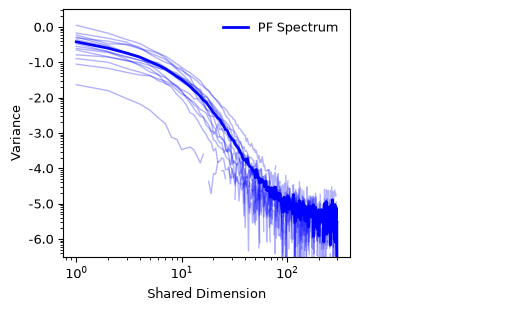

In [22]:
from dimensionality_manuscript.figure_scripts.figure4 import placefield_spectra

plt.close('all')
fig = placefield_spectra(
    results,
    ylim_range=(-6.5, 0.5),
    fontsize=9,
    figsize=(5, 3),
    activity_parameters_name="default",
    smooth_widths=(None, None),
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
)
plt.show()

save = False
if save:
    save_figure(fig, figure_path / "placefield_spectra")

## Parametric tuning-curve model spectrum vs empirical `ss_cv`

Rebuild the `N x P` (neurons x positions) tuning-curve matrix from the per-neuron
`TilburyFitConfig` fits (plain Gaussian control and asymmetric generalized Gaussian),
apply the same row-centering / `(P-1)` scaling that `StimSpaceSpectra` uses (`_to_g`),
and take the eigenvalues of the position covariance (squared singular values). These are
directly comparable to the empirical cross-validated shared-variance spectrum `ss_cv`.

Note: the model uses only the best environment's bins, whereas empirical `ss_cv` spans
`envs * valid_bins`, so the two spectra can have different lengths; they are plotted by
dimension index.

In [1]:
# Parameters matching the TilburyFitConfig defaults (raw activity, reliable/active
# neurons, no smoothing, no ITI) so the empirical ss_cv is the closest apples-to-apples
# comparison to the fitted tuning-curve model.
DEFAULT_SS_PARAMS = dict(
    activity_parameters_name="raw",
    smooth_widths=(None, None),
    reliability_fraction_active_thresholds=(0.3, 0.1),
    include_iti=False,
)

# CVPCA selection matching the TilburyFitConfig activity handling. Spatial eigenvectors
# (on_stimuli=True) put the spectrum in position space, the same space as the model /
# ss_cv spectra, so lengths line up.
DEFAULT_CVPCA_PARAMS = dict(
    spks_type="sigrebase",
    center=True,
    use_fast_sampling=True,
    activity_parameters_name="raw",
    use_spatial_eigenvectors=True,
)


def eval_gaussian_batch(theta, params):
    """Plain-Gaussian tuning curves for all neurons.

    Parameters
    ----------
    theta : np.ndarray
        Position bin centres, shape ``(P,)``.
    params : np.ndarray
        Packed control parameters, shape ``(N, 4)`` = ``[b, A, phi, sigma]``.

    Returns
    -------
    np.ndarray
        Tuning curves, shape ``(N, P)``.
    """
    b = params[:, 0:1]
    A = params[:, 1:2]
    phi = params[:, 2:3]
    sigma = params[:, 3:4]
    diff = theta[None, :] - phi
    return b + A * np.exp(-0.5 * (diff / np.clip(sigma, 1e-6, None)) ** 2)


def eval_tilbury_batch(theta, params):
    """Asymmetric generalized-Gaussian (Tilbury) tuning curves for all neurons.

    Parameters
    ----------
    theta : np.ndarray
        Position bin centres, shape ``(P,)``.
    params : np.ndarray
        Packed parameters, shape ``(N, 6)`` = ``[b, A, phi, sigma_left, sigma_right, p]``.

    Returns
    -------
    np.ndarray
        Tuning curves, shape ``(N, P)``.
    """
    b = params[:, 0:1]
    A = params[:, 1:2]
    phi = params[:, 2:3]
    sl = params[:, 3:4]
    sr = params[:, 4:5]
    p = params[:, 5:6]
    diff = theta[None, :] - phi
    sigma = np.where(diff < 0, sl, sr)
    ratio = np.abs(diff) / np.clip(sigma, 1e-6, None)
    log_pow = np.clip(p * np.log(np.clip(ratio, 1e-12, None)), None, 30.0)
    return b + A * np.exp(-np.exp(log_pow))


def to_g(x):
    """Row-center across columns and scale so ``x @ x.T`` is the sample covariance.

    Mirrors ``StimSpaceSpectra._to_g`` so the resulting eigenvalues share the scale of
    the ``ss_*`` singular values.
    """
    return (x - x.mean(axis=1, keepdims=True)) / (x.shape[1] - 1) ** 0.5


def tuning_curve_spectrum(curves):
    """Eigenvalues of the position covariance of an ``(N, P)`` tuning-curve matrix.

    Parameters
    ----------
    curves : np.ndarray
        Tuning-curve matrix, shape ``(N, P)``.

    Returns
    -------
    np.ndarray
        Eigenvalues (squared singular values of the ``_to_g``-normalised matrix),
        sorted descending, length ``min(N, P)``.
    """
    if curves.shape[0] == 0:
        return np.array([])
    g = to_g(curves)
    sv = np.linalg.svd(g, compute_uv=False)
    return sv ** 2


def _session_index(agg, session):
    """Resolve a session identifier (session_uid str or int index) to an axis-0 index."""
    if isinstance(session, str):
        return agg.session_ids.index(session)
    return int(session)


def get_fit_params(results_fit, session):
    """Return ``(theta, gaussian_params, tilbury_params)`` for one session (padding removed).

    Parameters
    ----------
    results_fit : ResultsAggregator
        Aggregator over ``TilburyFitConfig`` results.
    session : str or int
        Session ``session_uid`` or axis-0 index.

    Returns
    -------
    theta : np.ndarray
        Position bin centres used in the fit, shape ``(P,)``.
    gaussian_params : np.ndarray
        Control-model params, shape ``(N, 4)``.
    tilbury_params : np.ndarray
        Generalized-Gaussian params, shape ``(N, 6)``.
    """
    sidx = _session_index(results_fit, session)
    theta = np.asarray(results_fit.objects["dist_centers"][sidx], dtype=float)
    n_tilb = int(results_fit.result_shapes["params"][sidx][0])
    n_gauss = int(results_fit.result_shapes["params_control"][sidx][0])
    tilbury = np.asarray(results_fit.arrays["params"][sidx][:n_tilb], dtype=float)
    gaussian = np.asarray(results_fit.arrays["params_control"][sidx][:n_gauss], dtype=float)
    return theta, gaussian, tilbury


def get_empirical_spectrum(agg, key, session, **params):
    """Empirical spectrum ``key`` for one session from an aggregator.

    Parameters
    ----------
    agg : ResultsAggregator
        Aggregator holding the spectrum (e.g. StimSpaceSpectra or CVPCA results).
    key : str
        Result key to pull (e.g. ``"ss_cv"``, ``"org_covariances"``).
    session : str or int
        Session ``session_uid`` or axis-0 index.
    **params
        Full parameter selection for ``agg`` (every param axis must be fixed so the
        result reduces to ``(n_sess, L)``).

    Returns
    -------
    np.ndarray
        The spectrum for the requested session, padding removed. Empty if the session
        has no stored result for this selection.
    """
    sidx = _session_index(agg, session)
    out = agg.sel(keys=[key], squeeze_ones=False, **params)
    spec = np.asarray(out[key][sidx], dtype=float)
    return spec[np.isfinite(spec)]


def _normalize(spec, mode):
    """Normalise a spectrum for shape comparison ('first', 'sum', or 'none')."""
    if spec.size == 0 or mode in (None, "none"):
        return spec
    if mode == "first":
        return spec / spec[0]
    if mode == "sum":
        return spec / np.nansum(np.where(spec > 0, spec, 0.0))
    raise ValueError(f"Unknown normalize mode {mode!r}")

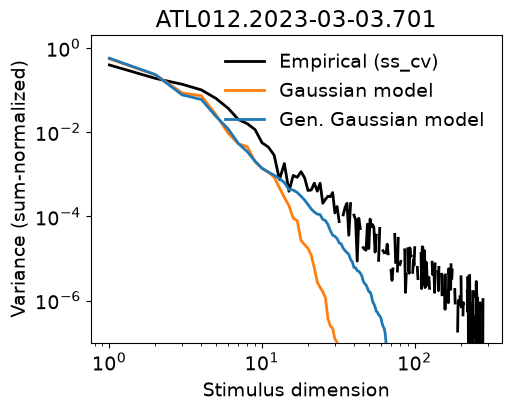

In [31]:
def compare_tuning_spectrum(session, ss_params=None, normalize="first", ax=None, figsize=(5, 4)):
    """Plot model tuning-curve eigenspectra against the empirical ``ss_cv`` for a session.

    Parameters
    ----------
    session : str or int
        Session ``session_uid`` or axis-0 index (shared by both aggregators).
    ss_params : dict or None
        Parameter selection for the empirical ``ss_cv`` (defaults to ``DEFAULT_SS_PARAMS``,
        matching the TilburyFitConfig defaults).
    normalize : {'first', 'sum', 'none'}
        Spectrum normalisation for shape comparison.
    ax : matplotlib.axes.Axes or None
        Axis to draw into; a new figure is created when ``None``.
    figsize : tuple of float
        Figure size (used only when ``ax`` is None).

    Returns
    -------
    matplotlib.figure.Figure
        The rendered figure.
    """
    ss_params = DEFAULT_SS_PARAMS if ss_params is None else ss_params

    theta, gauss_p, tilb_p = get_fit_params(results_fit, session)
    spec_gauss = tuning_curve_spectrum(eval_gaussian_batch(theta, gauss_p))
    spec_tilb = tuning_curve_spectrum(eval_tilbury_batch(theta, tilb_p))
    spec_emp = get_empirical_ss_cv(results, session, **ss_params)

    uid = results_fit.session_ids[_session_index(results_fit, session)]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    else:
        fig = ax.figure

    for spec, color, label in [
        (spec_emp, "black", "Empirical (ss_cv)"),
        (spec_gauss, "tab:orange", "Gaussian model"),
        (spec_tilb, "tab:blue", "Gen. Gaussian model"),
    ]:
        if spec.size == 0:
            continue
        s = _normalize(spec, normalize)
        s_pos = np.where(s > 0, s, np.nan)
        ax.plot(np.arange(len(s)) + 1, s_pos, color=color, label=label, linewidth=2.0)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Stimulus dimension")
    ylabel = "Variance" if normalize in (None, "none") else f"Variance ({normalize}-normalized)"
    ax.set_ylabel(ylabel)
    ax.set_title(uid)
    ax.legend(loc="upper right", frameon=False)
    return fig


# Sessions that actually have a stored TilburyFit result (skip missing cells).
_dist_centers = results_fit.objects["dist_centers"]
available_sessions = [uid for uid, dc in zip(results_fit.session_ids, _dist_centers) if dc is not None]

plt.close("all")
fig = compare_tuning_spectrum(available_sessions[22], normalize="sum")
ax = plt.gca()
ax.set_ylim(1e-7, 2e0)
plt.show()

In [ ]:
class TuningSpectrumViewer(Viewer):
    """Interactively choose a session and compare model eigenspectra to empirical ss_cv."""

    def __init__(self, results, results_fit, ss_params=None):
        self.results = results
        self.results_fit = results_fit
        self.ss_params = DEFAULT_SS_PARAMS if ss_params is None else ss_params

        dist_centers = results_fit.objects["dist_centers"]
        sessions = [uid for uid, dc in zip(results_fit.session_ids, dist_centers) if dc is not None]

        self.add_selection("session", options=sessions)
        self.add_selection("normalize", value="first", options=["first", "sum", "none"])

    def plot(self, state):
        return compare_tuning_spectrum(
            state["session"],
            ss_params=self.ss_params,
            normalize=state["normalize"],
        )


viewer = TuningSpectrumViewer(results, results_fit)
viewer.show()